**Target Audience:**
This analysis of Chicago 2025 crime data is intended for public safety officials, urban planners, and residents, providing insights into crime patterns across neighborhoods and times to support informed decisions on policing, safety, and community planning.

**Relevance and Motivation:**
The analysis focuses on crime trends in 2025 by type, location, and time, helping stakeholders identify hotspots, high-risk hours, and areas needing targeted interventions. The goal is to provide actionable insights for improving safety and allocating resources effectively.

# Load data

In [1]:
# Load required libraries, read the 2025 Chicago crime dataset, and create time-based features (month and hour) from the date column for analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("chicago_crime_2025.csv")

df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month
df["hour"] = df["date"].dt.hour

# Data Quality Checks

**Missing Values Table (Aggregate Table #1)**

In [2]:
# Create a table summarizing the count and percentage of missing values for each column to assess data quality
missing_table = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().sum()/len(df))*100
}).sort_values("missing_percent", ascending=False)

missing_table

,missing_count,missing_percent
location_description,1093,0.461897
latitude,96,0.040569
location,96,0.040569
longitude,96,0.040569
y_coordinate,96,0.040569
x_coordinate,96,0.040569
community_area,3,0.001268
ward,1,0.000423
description,0,0.000000
primary_type,0,0.000000


**Data validity checks**

In [3]:
# Generate summary statistics (count, mean, standard deviation, min, max, and percentiles) for numeric columns to assess data distribution
df.describe()

,id,date,beat,district,ward,community_area,x_coordinate,y_coordinate,year,latitude,longitude,month,hour
count,2.366330e+05,236633,236633.000000,236633.000000,236632.000000,236630.000000,2.365370e+05,2.365370e+05,236633.0,236537.000000,236537.000000,236633.000000,236633.000000
mean,1.386830e+07,2025-07-02 20:52:13.104089,1144.909362,11.218972,23.082170,36.345383,1.165673e+06,1.887166e+06,2025.0,41.845957,-87.667522,6.539874,12.479265
min,2.854500e+04,2025-01-01 00:00:00,111.000000,1.000000,1.000000,1.000000,1.093568e+06,1.813897e+06,2025.0,41.644590,-87.931147,1.000000,0.000000
25%,1.380234e+07,2025-04-07 21:08:00,531.000000,5.000000,10.000000,22.000000,1.154292e+06,1.860174e+06,2025.0,41.771731,-87.708835,4.000000,8.000000
50%,1.389323e+07,2025-07-04 00:00:00,1032.000000,10.000000,23.000000,32.000000,1.167661e+06,1.893593e+06,2025.0,41.863660,-87.660043,7.000000,13.000000
75%,1.398370e+07,2025-09-27 02:30:00,1731.000000,17.000000,34.000000,53.000000,1.176869e+06,1.909940e+06,2025.0,41.908487,-87.626358,9.000000,18.000000
max,1.412879e+07,2025-12-31 23:58:00,2535.000000,31.000000,50.000000,77.000000,1.205119e+06,1.951517e+06,2025.0,42.022559,-87.524529,12.000000,23.000000
std,5.956881e+05,NaN,708.300264,7.078032,13.936674,21.540363,1.626706e+04,3.143040e+04,0.0,0.086431,0.059233,3.340413,6.812487


In [4]:
# Group the data by crime type and count the number of incidents in each category
df.groupby("primary_type").size()

primary_type
ARSON                                  373
ASSAULT                              21559
BATTERY                              42538
BURGLARY                              9710
CONCEALED CARRY LICENSE VIOLATION      277
CRIMINAL DAMAGE                      26205
CRIMINAL SEXUAL ASSAULT               1672
CRIMINAL TRESPASS                     5322
DECEPTIVE PRACTICE                   14740
GAMBLING                                13
HOMICIDE                               426
HUMAN TRAFFICKING                       15
INTERFERENCE WITH PUBLIC OFFICER       915
INTIMIDATION                           143
KIDNAPPING                              89
LIQUOR LAW VIOLATION                   200
MOTOR VEHICLE THEFT                  17232
NARCOTICS                             7417
NON-CRIMINAL                             3
OBSCENITY                               55
OFFENSE INVOLVING CHILDREN            1541
OTHER NARCOTIC VIOLATION                10
OTHER OFFENSE                        1674

In [5]:
# Group the data by month and count the number of crimes in each month
df.groupby("month").size()

month
1     18487
2     16515
3     19741
4     19617
5     20459
6     21092
7     22624
8     21273
9     20283
10    20898
11    18312
12    17332
dtype: int64

In [6]:
# Calculate and display the number of unique values in each column to understand data diversity and identify categorical variables
df.nunique().sort_values(ascending=False)

id                      236632
case_number             236611
date                    122690
location                113543
longitude               113515
latitude                113514
y_coordinate             67639
x_coordinate             48958
block                    28292
updated_on                 633
iucr                       338
description                316
beat                       274
location_description       130
community_area              77
ward                        50
primary_type                31
fbi_code                    26
hour                        24
district                    23
month                       12
arrest                       2
domestic                     2
year                         1
dtype: int64

**Categorical Columns**

In [7]:
# Calculate the number of unique values for selected categorical variables to understand category diversity and help validate categorical data
categorical_cols = [
    "primary_type",       # type of crime
    "location_description", 
    "district",
    "ward",
    "community_area",
    "arrest",             # boolean, but categorical
    "domestic"
]

unique_counts = df[categorical_cols].nunique().sort_values(ascending=False)

unique_counts

location_description    130
community_area           77
ward                     50
primary_type             31
district                 23
arrest                    2
domestic                  2
dtype: int64

**Show Top Categories for Each Column**

In [8]:
# Display the top 5 most frequent values for each categorical variable to identify common categories
top_values = {col: df[col].value_counts().head(5) for col in categorical_cols}

top_values

{'primary_type': primary_type
 THEFT                  55040
 BATTERY                42538
 CRIMINAL DAMAGE        26205
 ASSAULT                21559
 MOTOR VEHICLE THEFT    17232
 Name: count, dtype: int64,
 'location_description': location_description
 STREET                62262
 APARTMENT             46431
 RESIDENCE             28114
 SIDEWALK              12031
 SMALL RETAIL STORE     9008
 Name: count, dtype: int64,
 'district': district
 8     15197
 12    14882
 1     13670
 6     13557
 18    13188
 Name: count, dtype: int64,
 'ward': ward
 27.0    11348
 28.0    10706
 42.0     8970
 6.0      8937
 24.0     8272
 Name: count, dtype: int64,
 'community_area': community_area
 25.0    11763
 8.0     11112
 28.0    10291
 32.0     8563
 43.0     8091
 Name: count, dtype: int64,
 'arrest': arrest
 False    198871
 True      37762
 Name: count, dtype: int64,
 'domestic': domestic
 False    191552
 True      45081
 Name: count, dtype: int64}

# Groupby Analysis

**Groupby #1 — Crimes by Type (Aggregate Table #2)**

In [9]:
# Group the dataset by crime type, count the number of incidents for each type, sort them in descending order, and display the top 15 most frequent crime types
crime_type_table = df.groupby("primary_type").size().sort_values(ascending=False)

crime_type_table.head(15)

primary_type
THEFT                         55040
BATTERY                       42538
CRIMINAL DAMAGE               26205
ASSAULT                       21559
MOTOR VEHICLE THEFT           17232
OTHER OFFENSE                 16742
DECEPTIVE PRACTICE            14740
BURGLARY                       9710
NARCOTICS                      7417
ROBBERY                        5816
WEAPONS VIOLATION              5444
CRIMINAL TRESPASS              5322
CRIMINAL SEXUAL ASSAULT        1672
OFFENSE INVOLVING CHILDREN     1541
SEX OFFENSE                    1309
dtype: int64

**Groupby #2 — Crimes by Month (Aggregate Table #3)**

In [10]:
# Group the dataset by month and count the number of crimes in each month
monthly_crime = df.groupby("month").size()

monthly_crime

month
1     18487
2     16515
3     19741
4     19617
5     20459
6     21092
7     22624
8     21273
9     20283
10    20898
11    18312
12    17332
dtype: int64

**Groupby #3 — Arrest Rate by Crime Type**

In [11]:
# Calculate the average arrest rate for each crime type by grouping on 'primary_type' and taking the mean of the 'arrest' column, 
# then sort in descending order to identify which crimes have the highest likelihood of resulting in an arrest
arrest_rate = df.groupby("primary_type")["arrest"].mean().sort_values(ascending=False)

arrest_rate.head(15)

primary_type
NON-CRIMINAL                         1.000000
PUBLIC INDECENCY                     1.000000
CONCEALED CARRY LICENSE VIOLATION    0.974729
NARCOTICS                            0.948092
LIQUOR LAW VIOLATION                 0.930000
GAMBLING                             0.923077
INTERFERENCE WITH PUBLIC OFFICER     0.915847
PROSTITUTION                         0.910053
WEAPONS VIOLATION                    0.779390
OBSCENITY                            0.509091
PUBLIC PEACE VIOLATION               0.506629
OTHER NARCOTIC VIOLATION             0.500000
HOMICIDE                             0.328638
CRIMINAL TRESPASS                    0.315483
OTHER OFFENSE                        0.202365
Name: arrest, dtype: float64

# APPLY / MAP USAGE

**Map Example — Month Names**

In [12]:
# Map numeric month values to their corresponding month names for better readability
month_map = {
1:"Jan",2:"Feb",3:"Mar",4:"Apr",
5:"May",6:"Jun",7:"Jul",8:"Aug",
9:"Sep",10:"Oct",11:"Nov",12:"Dec"
}

df["month_name"] = df["month"].map(month_map)

df.head()

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location,month,hour,month_name
0,14024965,JJ484232,2025-01-01,007XX S INDEPENDENCE BLVD,1562,SEX OFFENSE,AGGRAVATED CRIMINAL SEXUAL ABUSE,RESIDENCE,False,False,...,1151379.0,1896339.0,2025,2025-11-12T15:45:20.000,41.871437,-87.719700,"{'latitude': '41.871436933', 'longitude': '-87...",1,0,Jan
1,14034324,JJ443201,2025-01-01,026XX S RIDGEWAY AVE,1562,SEX OFFENSE,AGGRAVATED CRIMINAL SEXUAL ABUSE,RESIDENCE,False,False,...,1151797.0,1886181.0,2025,2025-11-22T15:41:52.000,41.843554,-87.718433,"{'latitude': '41.84355397', 'longitude': '-87....",1,0,Jan
2,14035171,JJ496186,2025-01-01,081XX S CALIFORNIA AVE,1562,SEX OFFENSE,AGGRAVATED CRIMINAL SEXUAL ABUSE,SCHOOL - PUBLIC BUILDING,False,False,...,1159127.0,1850529.0,2025,2025-11-23T15:41:46.000,41.745573,-87.692508,"{'latitude': '41.745572921', 'longitude': '-87...",1,0,Jan
3,14045279,JJ508875,2025-01-01,080XX S MARYLAND AVE,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,RESIDENCE,False,False,...,1183298.0,1851901.0,2025,2025-12-05T15:52:17.000,41.748810,-87.603899,"{'latitude': '41.748809737', 'longitude': '-87...",1,0,Jan
4,14047551,JJ512119,2025-01-01,013XX W 97TH PL,1310,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE,False,False,...,1169144.0,1840175.0,2025,2025-12-07T15:41:23.000,41.716949,-87.656102,"{'latitude': '41.71694947', 'longitude': '-87....",1,0,Jan


**Apply Example — Time of Day Category**

In [13]:
# Define a function to categorize each crime by the time of day based on the hour, then apply it to create a new 'time_of_day' column for easier analysis
def time_of_day(hour):
    if hour < 6:
        return "Late Night"
    elif hour < 12:
        return "Morning"
    elif hour < 18:
        return "Afternoon"
    else:
        return "Evening"

df["time_of_day"] = df["hour"].apply(time_of_day)

df.head()

,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,y_coordinate,year,updated_on,latitude,longitude,location,month,hour,month_name,time_of_day
0,14024965,JJ484232,2025-01-01,007XX S INDEPENDENCE BLVD,1562,SEX OFFENSE,AGGRAVATED CRIMINAL SEXUAL ABUSE,RESIDENCE,False,False,...,1896339.0,2025,2025-11-12T15:45:20.000,41.871437,-87.719700,"{'latitude': '41.871436933', 'longitude': '-87...",1,0,Jan,Late Night
1,14034324,JJ443201,2025-01-01,026XX S RIDGEWAY AVE,1562,SEX OFFENSE,AGGRAVATED CRIMINAL SEXUAL ABUSE,RESIDENCE,False,False,...,1886181.0,2025,2025-11-22T15:41:52.000,41.843554,-87.718433,"{'latitude': '41.84355397', 'longitude': '-87....",1,0,Jan,Late Night
2,14035171,JJ496186,2025-01-01,081XX S CALIFORNIA AVE,1562,SEX OFFENSE,AGGRAVATED CRIMINAL SEXUAL ABUSE,SCHOOL - PUBLIC BUILDING,False,False,...,1850529.0,2025,2025-11-23T15:41:46.000,41.745573,-87.692508,"{'latitude': '41.745572921', 'longitude': '-87...",1,0,Jan,Late Night
3,14045279,JJ508875,2025-01-01,080XX S MARYLAND AVE,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,RESIDENCE,False,False,...,1851901.0,2025,2025-12-05T15:52:17.000,41.748810,-87.603899,"{'latitude': '41.748809737', 'longitude': '-87...",1,0,Jan,Late Night
4,14047551,JJ512119,2025-01-01,013XX W 97TH PL,1310,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE,False,False,...,1840175.0,2025,2025-12-07T15:41:23.000,41.716949,-87.656102,"{'latitude': '41.71694947', 'longitude': '-87....",1,0,Jan,Late Night


# CHARTS

**Chart 1 — Top Crime Types**

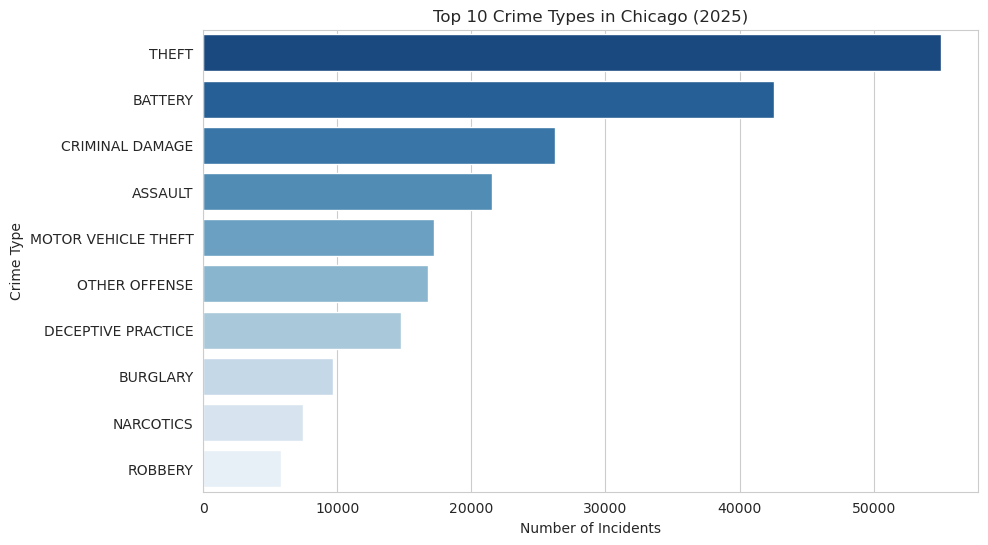

In [14]:
# Bar chart showing the top 10 most frequent crime types in Chicago for 2025,
# including chart title, axis labels, colors, and rotated x-axis labels for readability
plt.figure(figsize=(10,6))

top_10_crimes = df["primary_type"].value_counts().head(10)

sns.barplot(
    x=top_10_crimes.values,
    y=top_10_crimes.index,
    hue=top_10_crimes.index,  # assign hue to the same as y variable
    palette="Blues_r",
    dodge=False,               # ensures bars don't split by hue
    legend=False               # hides the unnecessary legend
)

plt.title("Top 10 Crime Types in Chicago (2025)")
plt.xlabel("Number of Incidents")
plt.ylabel("Crime Type")
plt.show()

**Chart 2 — Crime Trend by Month**

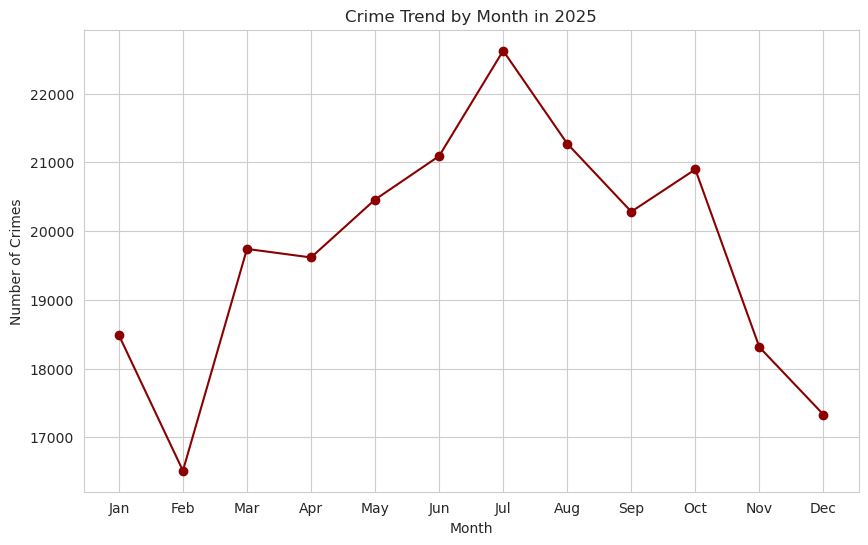

In [15]:
# Plot a line chart showing the monthly trend of crimes in 2025,
# with markers for each month and labeled axes to visualize seasonal patterns
plt.figure(figsize=(10,6))
monthly_crime = df.groupby("month").size()
plt.plot(monthly_crime.index, monthly_crime.values, marker="o", color="darkred")
plt.title("Crime Trend by Month in 2025")
plt.xlabel("Month")
plt.ylabel("Number of Crimes")
plt.xticks(ticks=range(1,13), labels=[month_map[i] for i in range(1,13)])
plt.grid(True)
plt.show()

**Chart 3 — Crime Distribution by Hour**

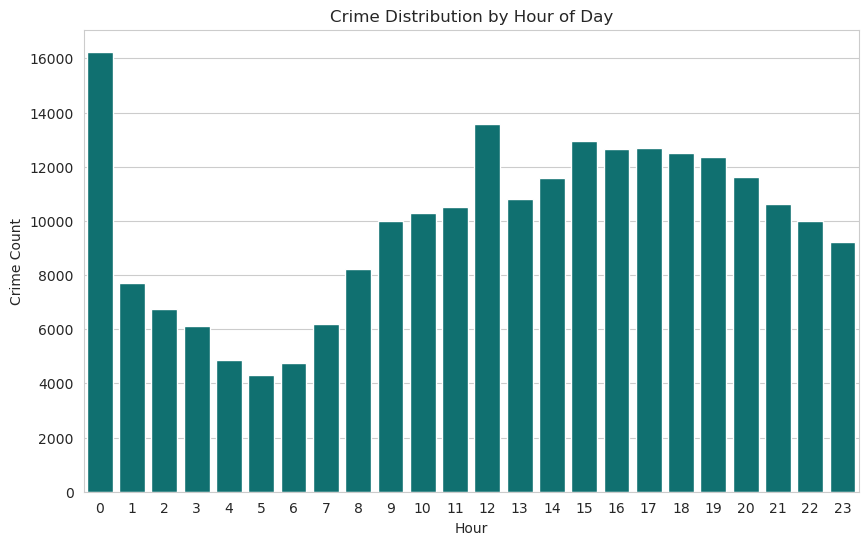

In [16]:
# Create a count plot to visualize the distribution of crimes by hour of the day in 2025,
# helping to identify peak crime hours; includes axis labels, title, and color for readability
plt.figure(figsize=(10,6))

sns.countplot(
    x="hour",
    data=df,
    color="teal"
)

plt.title("Crime Distribution by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Crime Count")

plt.show()

**Chart 4 — Arrest Rate by Crime Type**

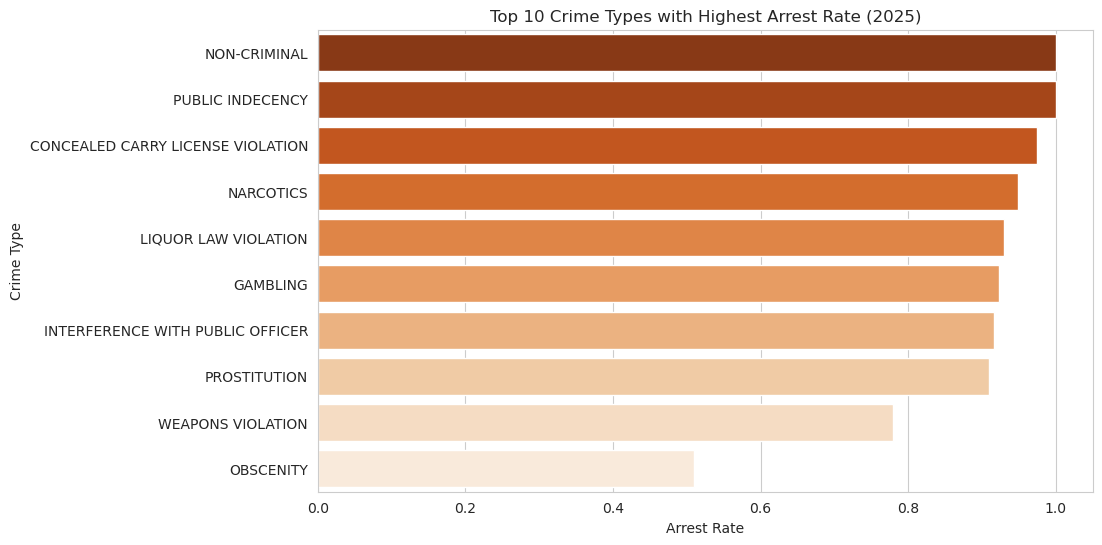

In [17]:
# Horizontal bar chart showing the top 10 crime types with the highest arrest rates in 2025
plt.figure(figsize=(10,6))

top_arrest = df.groupby("primary_type")["arrest"].mean().sort_values(ascending=False).head(10)

sns.barplot(
    x=top_arrest.values,
    y=top_arrest.index,
    hue=top_arrest.index,  # Assign hue to the same as y variable
    palette="Oranges_r",
    dodge=False,            # Ensures a single bar per category
    legend=False            # Hides the redundant legend
)

plt.title("Top 10 Crime Types with Highest Arrest Rate (2025)")
plt.xlabel("Arrest Rate")
plt.ylabel("Crime Type")
plt.show()

**Chart 5 — Crime by Time of Day (Using apply variable)**

In [18]:
# Group the data by time-of-day categories and count the number of crimes in each category
time_of_day_crime = df.groupby("time_of_day").size()

time_of_day_crime

time_of_day
Afternoon     74279
Evening       66322
Late Night    46015
Morning       50017
dtype: int64

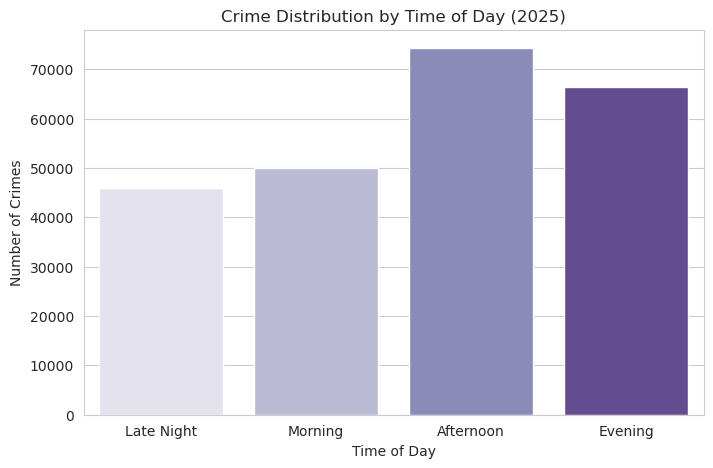

In [19]:
# Bar chart showing the number of crimes for each time-of-day category in 2025, highlighting patterns such as peak crime periods
plt.figure(figsize=(8,5))

time_of_day_counts = df.groupby("time_of_day").size().reindex(["Late Night","Morning","Afternoon","Evening"])

sns.barplot(
    x=time_of_day_counts.index,
    y=time_of_day_counts.values,
    hue=time_of_day_counts.index,  # Assign hue to same as x variable
    palette="Purples",
    dodge=False,                   # Single bar per category
    legend=False                   # Remove redundant legend
)

plt.title("Crime Distribution by Time of Day (2025)")
plt.xlabel("Time of Day")
plt.ylabel("Number of Crimes")
plt.show()

**Chart 6 — Day-of-Week vs Hour Crime Heatmap**

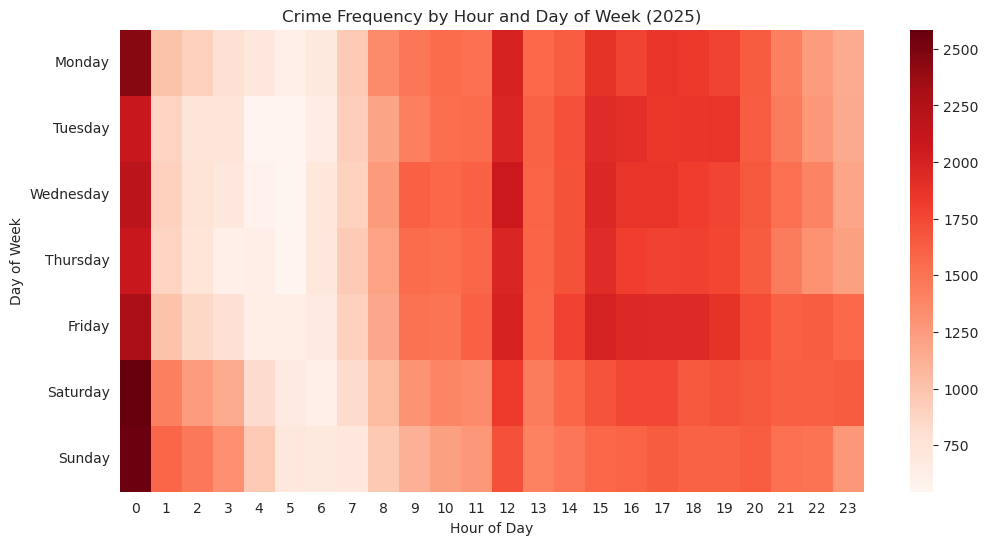

In [20]:
# Create a heatmap showing the frequency of crimes by hour and day of the week in 2025
# Steps:
# 1. Extract the day of the week from the 'date' column
# 2. Define the correct order of days for plotting
# 3. Group by day of week and hour to count incidents
# 4. Plot a heatmap to visualize patterns of crime frequency across different times and days
df["day_of_week"] = df["date"].dt.day_name()

day_order = [
"Monday","Tuesday","Wednesday",
"Thursday","Friday","Saturday","Sunday"
]

df["day_of_week"] = pd.Categorical(df["day_of_week"], categories=day_order, ordered=True)

crime_heatmap = df.groupby(["day_of_week","hour"]).size().unstack()

plt.figure(figsize=(12,6))

sns.heatmap(
    crime_heatmap,
    cmap="Reds"
)

plt.title("Crime Frequency by Hour and Day of Week (2025)")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.show()

**Chart 7 — Crimes by Community Area**

In [21]:
# Map community area numbers to neighborhood names and create a bar chart
# showing the top Chicago community areas with the highest crime counts in 2025
# https://chicagocommunitygardens.org/communityareaslist/
community_map = {
1:"Rogers Park",2:"West Ridge",3:"Uptown",4:"Lincoln Square",5:"North Center",
6:"Lake View",7:"Lincoln Park",8:"Near North Side",9:"Edison Park",10:"Norwood Park",
11:"Jefferson Park",12:"Forest Glen",13:"North Park",14:"Albany Park",15:"Portage Park",
16:"Irving Park",17:"Dunning",18:"Montclare",19:"Belmont Cragin",20:"Hermosa",
21:"Avondale",22:"Logan Square",23:"Humboldt Park",24:"West Town",25:"Austin",
26:"West Garfield Park",27:"East Garfield Park",28:"Near West Side",29:"North Lawndale",
30:"South Lawndale",31:"Lower West Side",32:"Loop",33:"Near South Side",34:"Armour Square",
35:"Douglas",36:"Oakland",37:"Fuller Park",38:"Grand Boulevard",39:"Kenwood",
40:"Washington Park",41:"Hyde Park",42:"Woodlawn",43:"South Shore",44:"Chatham",
45:"Avalon Park",46:"South Chicago",47:"Burnside",48:"Calumet Heights",49:"Roseland",
50:"Pullman",51:"South Deering",52:"East Side",53:"West Pullman",54:"Riverdale",
55:"Hegewisch",56:"Garfield Ridge",57:"Archer Heights",58:"Brighton Park",59:"McKinley Park",
60:"Bridgeport",61:"New City",62:"West Elsdon",63:"Gage Park",64:"Clearing",
65:"West Lawn",66:"Chicago Lawn",67:"West Englewood",68:"Englewood",69:"Greater Grand Crossing",
70:"Ashburn",71:"Auburn Gresham",72:"Beverly",73:"Washington Heights",74:"Mount Greenwood",
75:"Morgan Park",76:"O'Hare",77:"Edgewater"
}

df["community_name"] = df["community_area"].map(community_map)

community_crime = df.groupby("community_name").size().sort_values(ascending=False).head(10)

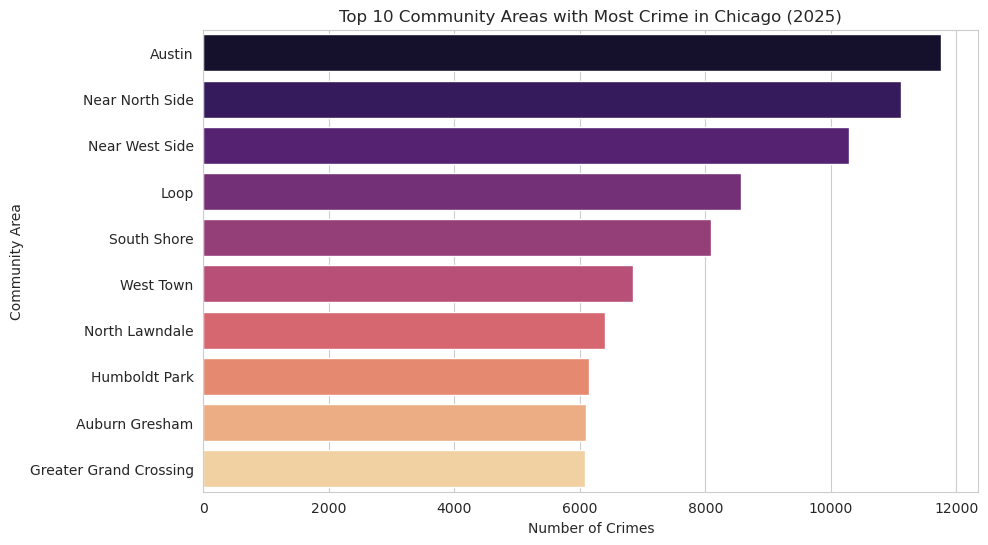

In [22]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=community_crime.values,
    y=community_crime.index,
    hue=community_crime.index,
    palette="magma",
    dodge=False,
    legend=False
)

plt.title("Top 10 Community Areas with Most Crime in Chicago (2025)")
plt.xlabel("Number of Crimes")
plt.ylabel("Community Area")

plt.show()